# Laboratory 2.4: Linear Regression contd.

In this practice you will extend your Linear Regression code to a more general case. Here you will need the `synthetic_dataset.csv` present in the .zip file you downloaded alongside this notebook.

In addition, we will be using the following libraries:
- Data management:
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
    - [scipy](https://scipy.org/)
- Modelling:
    - [scikit-learn](https://scikit-learn.org)
- Plotting:
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)
    
### **All the things you need to do are marked by a "TODO" comment nearby. Make sure you *read carefully everything before working* and solve each point before submitting your solution.**

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import os
import sys
# Get the absolute path of the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add it to sys.path
sys.path.insert(0, project_root)

### Custom Linear Regression model

You are going to be working with the following class that you already know from the previous practice, so feel free to recycle as much code as you want (or can). In this case, you will be enhancing its functionalities, getting a more general function than the one you implemented before. 

**For now, just continue with the practice and do not fill anything, you will come back later to fill the gaps.**

In [63]:
from src.Lab_2_4_LR2 import LinearRegressor


**Data**: Remember, from the previous lab session, we had the following univariate dataset:

In [64]:
# Define data to use in this practice
x = np.array([0, 3, 2, 1, 4, 6, 7, 8, 9, 10])
y = np.array([2, 3, 2, 4, 5, 7, 9, 9, 10, 13])

Use the code *you wrote* from the previous practice (not the sklearn version) to fit the data in the following cell

In [65]:
linreg = LinearRegressor()
linreg.fit(x, y)

Before we get into the things you'll do today, let's construct a function that provides the values for the $R^2$, RMSE and MAE. For this, the inputs of this function are the true $y$ values and the predicted $\hat{y}$ values

In [66]:
from src.Lab_2_4_LR2 import evaluate_regression

In [67]:
# Obtain regression performance metrics
y_pred = linreg.predict(x)
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)

{'R2': np.float64(0.9201359388275276), 'RMSE': np.float64(1.012647295683223), 'MAE': np.float64(0.8945454545454539)}


## Polynomial regression

In the previous practice, you have trained a model assuming that the relationship between input and output is linear. However, in most real cases this is not common and the relationship between input and output is not linear. In this section, we are going to learn how to deal with non-linear relationships when using linear models. Read `synthetic_dataset.csv` and train a linear regression model. 

*The target variable is the last column of the dataset*

In [68]:
data = pd.read_csv("../data/synthetic_dataset.csv")

# TODO: Obtain inputs and output from data
X = data[["Input1","Input2","Input3","Input4"]]
y = data["Output"]

In this case we will skip the preprocessing and go straight to the modelling phase. Therefore, fit the model here.

In [69]:
# TODO: Train linear regression model
linreg = LinearRegressor()
linreg.fit(np.array(X),np.array(y))


In [70]:
# TODO: Obtain and print the regression performance metrics
from src.Lab_2_4_LR2 import evaluate_regression
y_predict = linreg.predict(X)

evaluation_metrics = evaluate_regression(y,y_predict)
print(evaluation_metrics)

{'R2': np.float64(0.5452814241832913), 'RMSE': np.float64(3.1936452748702813), 'MAE': np.float64(2.2373945210247843)}


If you trained the model well, the $R^2$ metric will be terrible, in the order of $0.5$. **What happened here?** Let's try to clear this via the *study of the residuals*.

Create a function to plot the residuals of the model. This function shall:
- Create a **histogram** of the residuals.
- Create a **Q-Q plot** of the residuals.
- Create a **scatterplot of the residuals against each input variable, the true output variable and the predictions**.

**Why do we want to check the residuals this way?** 

> Write your answer here
Nos interesa ver los residuals (e= y_pred-y_true) para saber si se comportan como algo parecido a una normal centrada en 0.
--> Lo primero es que en un modelo lineal bien comportado, los residuals deberían verse como algo cercano a una normal 
centrada en 0. Esto va a ser el primer punto útil de evaluar nuestro residuals y lo vamos a hacer con un histograma.
--> Vamos a usar también un QQ plot, veremos de manera mas precisa cúanto nos alejamos/acercamos de tener un comportamiento
de normal. (ver cúanto nos acercamos a la línea roja)
--> Podemos usar también scatter plots entre residuals y variables para ver patrones de manera individualizada


In [71]:
def plot_residuals(data, output_column, prediction_column):
    """
    Plot residuals of a model against all variables in the DataFrame, using box plots for
    categorical variables and scatter plots for continuous variables. Additionally, plot
    a histogram and a QQ-plot of the residuals.

    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        output_column (str): The name of the output column.
        prediction_column (str): The name of the prediction column.
    """
    # TODO: Calculate residuals
    residuals = data[output_column] - data[prediction_column]
    
    num_features = len(data.columns) - 2  # Exclude output and prediction columns

    # Determine the number of rows and columns for subplots
    num_rows = int(np.ceil(np.sqrt(num_features + 4)))  # Add 4 for histogram, Q-Q plot, true output vs residuals, and predictions vs residuals
    num_cols = int(np.ceil((num_features + 4) / num_rows))

    # Plot histogram of residuals
    plt.figure(figsize=(5 * num_cols, 4 * num_rows))
    plt.subplot(num_rows, num_cols, 1)
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')

    # TODO: Plot Q-Q plot of residuals (tip: use stats.probplot from scipy)
    plt.subplot(num_rows, num_cols, 2)
    stats.probplot(residuals, dist = "norm", plot=plt)       # Fill the code here
    plt.title('Q-Q Plot of Residuals')

    # TODO: Plot residuals against output variable
    plt.subplot(num_rows, num_cols, 3)
    plt.scatter(data[output_column], residuals, alpha=0.5)     # Fill the code here
    plt.title('Residuals vs True Output')
    plt.xlabel('True Output')
    plt.ylabel('Residuals')

    # Plot residuals against prediction variable
    plt.subplot(num_rows, num_cols, 4)
    plt.scatter(data[prediction_column], residuals, alpha=0.5)   # Use this as example for later
    plt.title('Residuals vs Predictions')
    plt.xlabel('Predictions')
    plt.ylabel('Residuals')

    # TODO: Plot residuals against each input variable
    for i, col in enumerate(data.columns):
        if col not in [output_column, prediction_column]:
            plt.subplot(num_rows, num_cols, i + 5)
            plt.scatter(data[col], residuals, alpha=0.5)   # Fill the code here
            plt.title(f'Residuals vs {col}')
            plt.xlabel(col)
            plt.ylabel('Residuals')

    plt.tight_layout()
    plt.show()

Now, **print the coefficients** of the model **alongside the plots** you can generate with the previous function

Coefficients of the model: {'Input1': np.float64(-0.0019118098357402448), 'Input2': np.float64(-0.005980294661835375), 'Input3': np.float64(1.6303240019912557), 'Input4': np.float64(3.059308730603961)}


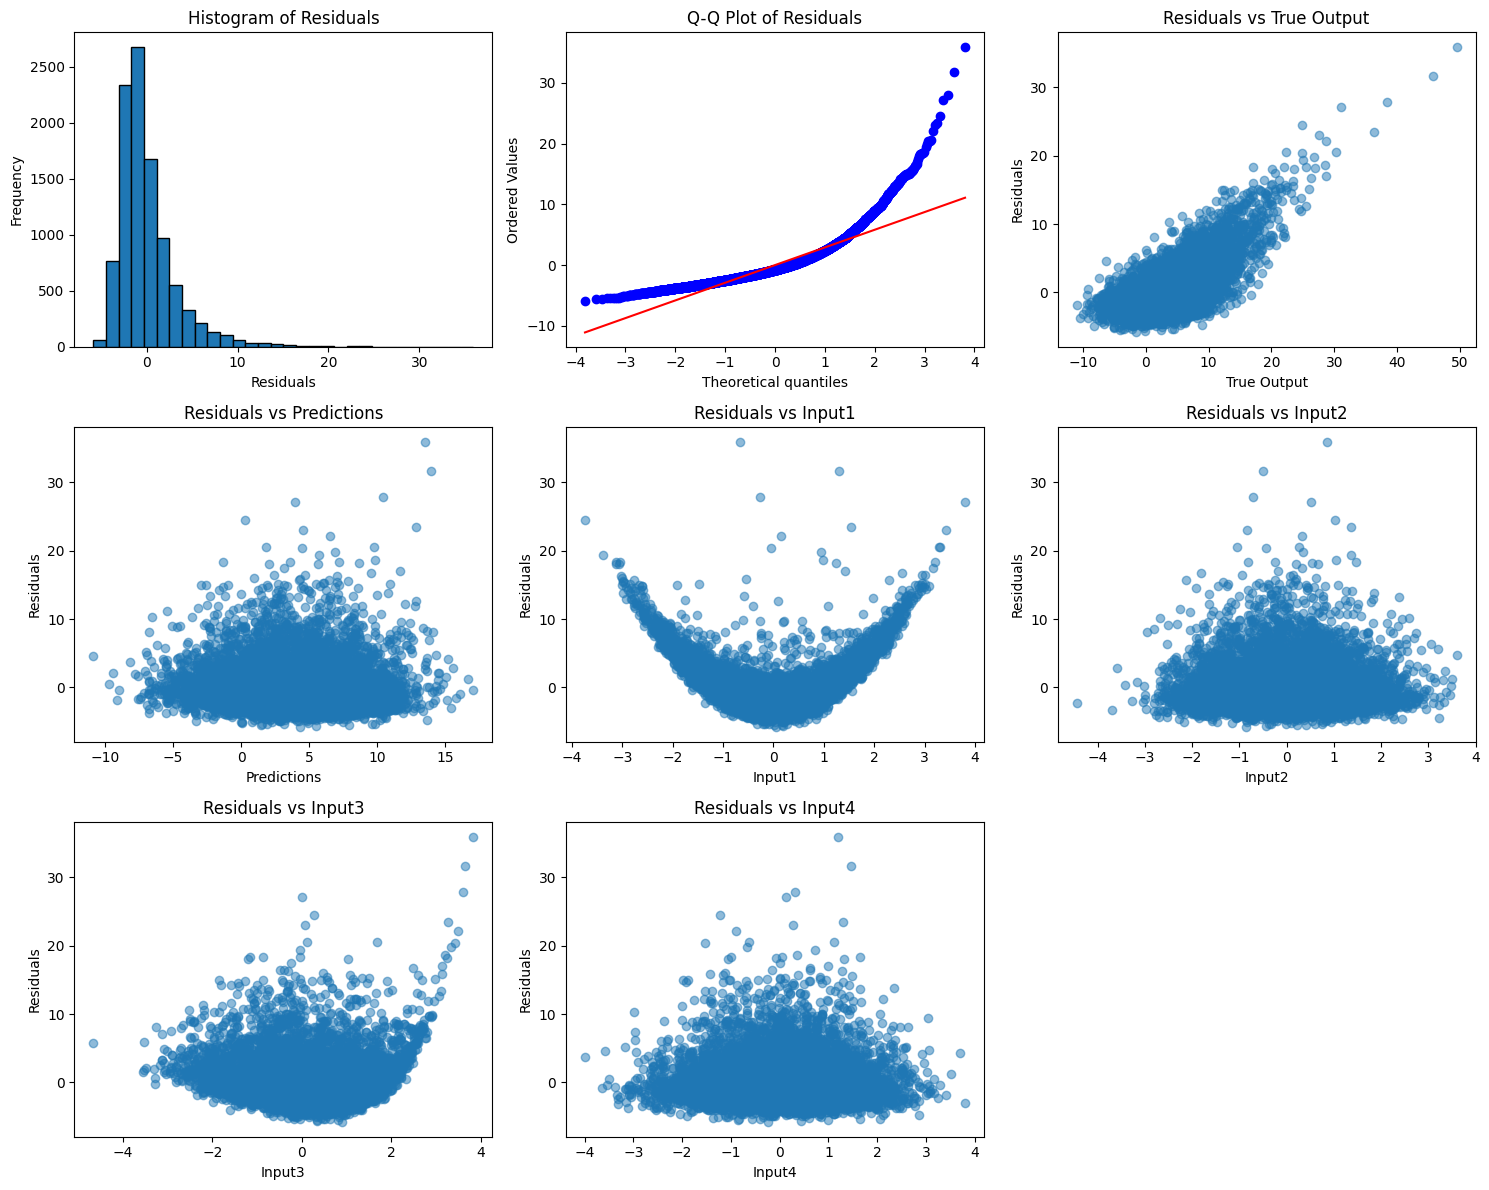

In [72]:
# TODO:  First, construct a dictionary of the coefficients to print them
coef_dict = {'Input' + str(i+1): coef for i, coef in enumerate(linreg.coefficients)}
print(f"Coefficients of the model: {coef_dict}")

# Plot the residuals for the predictions
data["Predictions"] = linreg.predict(X)
plot_residuals(data, 'Output', 'Predictions')

**What are we seeing here? Is there any way to improve the model?**
> Write your answer here
Vemos que hay una cola larga positiva en el histograma. No obtenemos esa distribución aparentemente normal de un modelo lineal bien 
comportado. Observamos errores bastante importantes en valores altos. Esto se confirma de nuevo al observar el qq-plot, donde vemos clara discrepancia con el modelo normal debido a valores altos (sobretodo). Observando individualmente las variables, vemos que en general hay mucho ruido en los residuals y pocos patrones claros (salvo en alguna variable que muestra además patrones no lineales)

As you may expect, you should see some higher-order contribution to the behavior of the data, since some of the residuals have clear structures. In particular, `Input1` has a higher-order polynomial contribution (*which order do you think?*), while `Input2` has an *exponential* form. 

In order to fit a regression model with these contributions, construct a new dataframe where each column corresponds to the desired manipulation of each variable. Then, fit the regression model and see the results.

* Also, pay attention to the fact that you can use whatever contribution you see fit here, not just these previous ones.

In [73]:
# 
input1 = data["Input1"]
input3 = data["Input3"]
input4 = data["Input4"]
output = data["Output"]
data_transf = pd.DataFrame({'Input1': input1 ** 2,   # Substitute "None" by the degree you think works here
                            'Input2': np.exp(input3),
                            'Input3': input4,
                            'Output': output})
X_transf = data_transf.iloc[:,:3].values

# Train linear regression model
linreg = LinearRegressor()
linreg.fit(X_transf, y)

# Evaluate the metrics to see the behavior
y_pred = linreg.predict(X_transf)
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)

{'R2': np.float64(0.9557524745534756), 'RMSE': np.float64(0.9962304737909358), 'MAE': np.float64(0.7956340344398113)}


Now, print again the coefficients for the model and plot the residuals as you did before.

**What do you observe?**
> Write your answer here
Vemos que los errores RMSE y MAE se han reducido drásticamente, nuestro modelo comete un error mucho menor al usar un regresor al cuadrado.
R2 es alto, lo que nos confirma que nuestro modelo explica gran cantidad de la variabilidad real de los datos, aunque hay que tener cuidado de no sobreajustar demasiado...

Coefficients of the model: {'Input1': np.float64(1.9985407741302774), 'Input2': np.float64(0.995125930021854), 'Input3': np.float64(2.9880699293625486)}


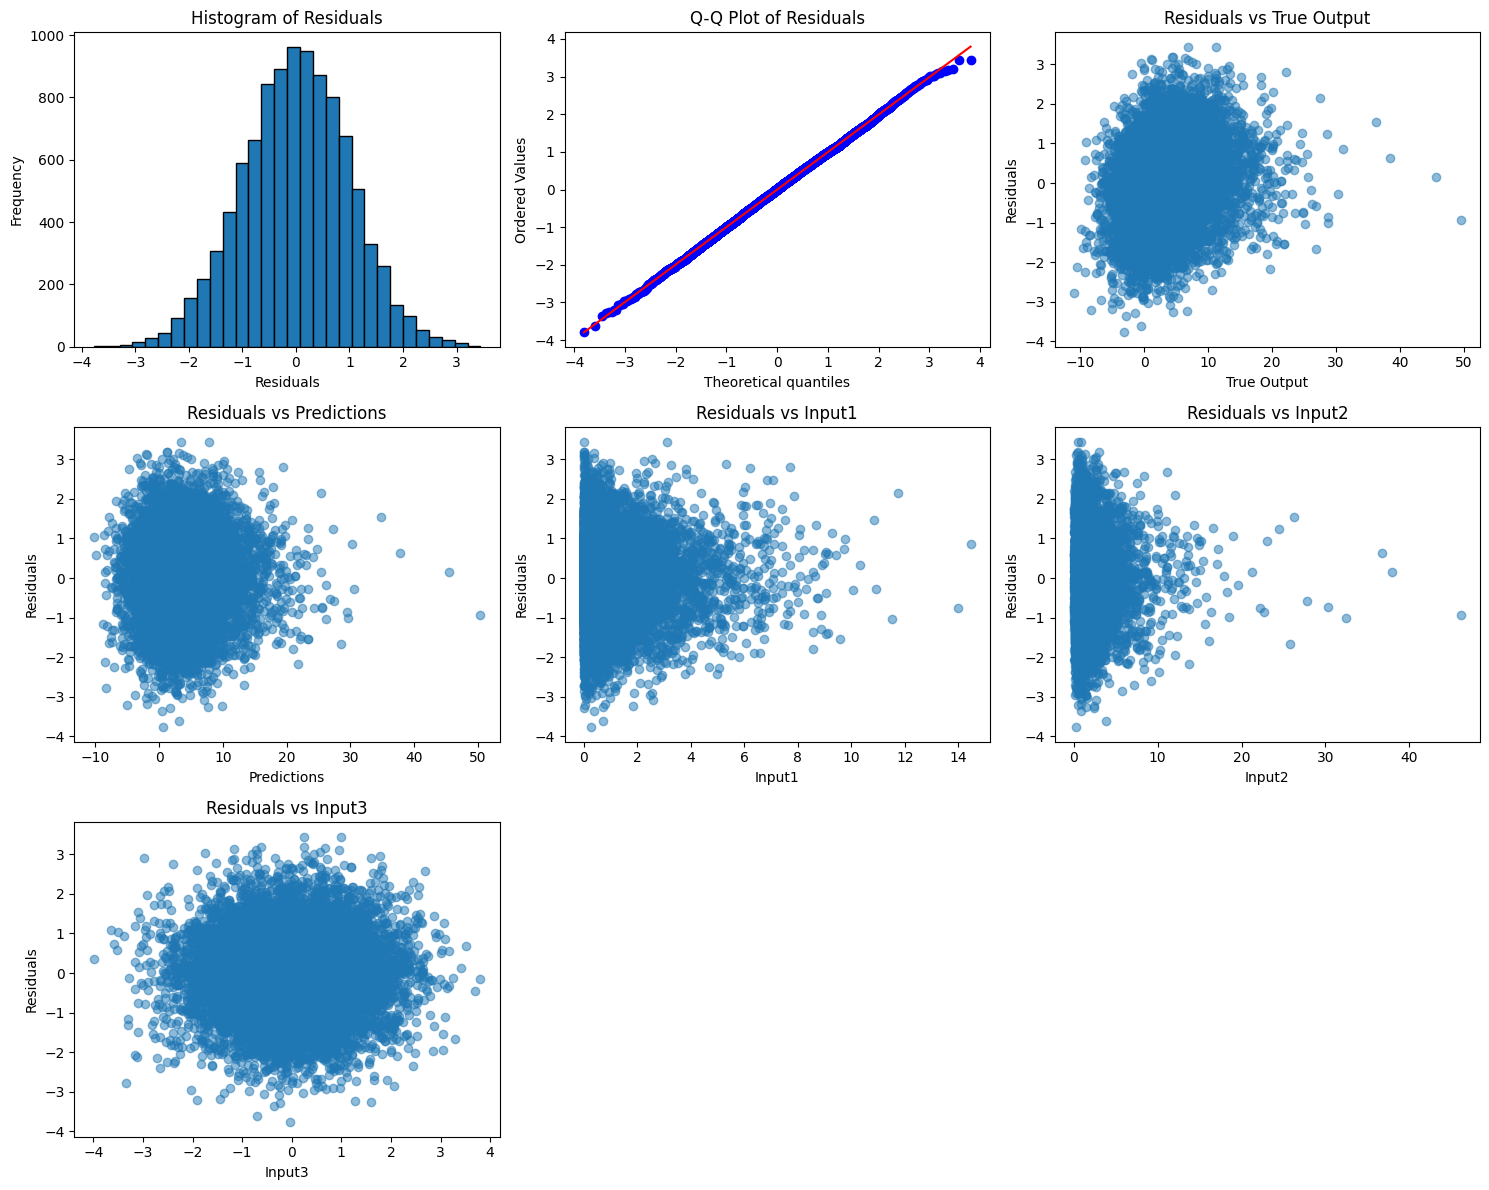

In [74]:
coef_dict = {'Input' + str(i+1): coef for i, coef in enumerate(linreg.coefficients)}
print(f"Coefficients of the model: {coef_dict}")
data_transf["Predictions"] = linreg.predict(X_transf)
plot_residuals(data_transf, 'Output', 'Predictions')

## Categorical variables

Linear regression, as is, can not deal with categorical variables. Therefore, we need to encode the variables when preprocessing the data. Complete the one-hot-encode function below. Take into account that strings shall be treated automatically as categorical variables.
<center>

![Image](https://miro.medium.com/v2/resize:fit:1358/1*ggtP4a5YaRx6l09KQaYOnw.png)

</center>

In [75]:
from src.Lab_2_4_LR2 import one_hot_encode


We will use this in a usual dataset from the internet. If everything is well, you should be able to run the following code as-is.

In [76]:
# Load the dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)


y = data['charges'].values
X = data.drop(columns=['charges']).values

# Preprocess the data
# Identify categorical columns for one-hot encoding
categorical_columns = [data.columns.get_loc(col) for col in ['sex', 'smoker', 'region']]

# One-hot encode categorical variables
X_encoded = one_hot_encode(X, categorical_columns, drop_first=True)
X_encoded = X_encoded.astype(float)                                  # Watch out for this!

# Instantiate and fit the LinearRegressor
model = LinearRegressor()
model.fit(X_encoded, y)

# Predict and evaluate
y_pred = model.predict(X_encoded)
evaluation_metrics = evaluate_regression(y, y_pred)
evaluation_metrics


{'R2': np.float64(0.7509130345985207),
 'RMSE': np.float64(6041.6796511744515),
 'MAE': np.float64(4170.886894163564)}

Compare yourself with scikit

In [77]:
from sklearn.linear_model import LinearRegression

# Load the dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)

# Preprocess the data
# TODO: One-hot encode categorical variables. Use pd.get_dummies()
data_encoded = pd.get_dummies(data) 

# Split the data into features (X) and target (y)
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

# Instantiate the LinearRegression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X, y)

# Make predictions on the test data
y_pred = model.predict(X)

# Evaluate the model
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)


{'R2': np.float64(0.7509130345985205), 'RMSE': np.float64(6041.679651174452), 'MAE': np.float64(4170.886894163588)}


### Colored residuals

Now that we have categorical variables, the relationship between inputs and outputs might differ for different levels of the categorical variables. Therefore, you will modify the `plot_residuals` function to **color the scatter plots based on the value of a specific categorical variable**.

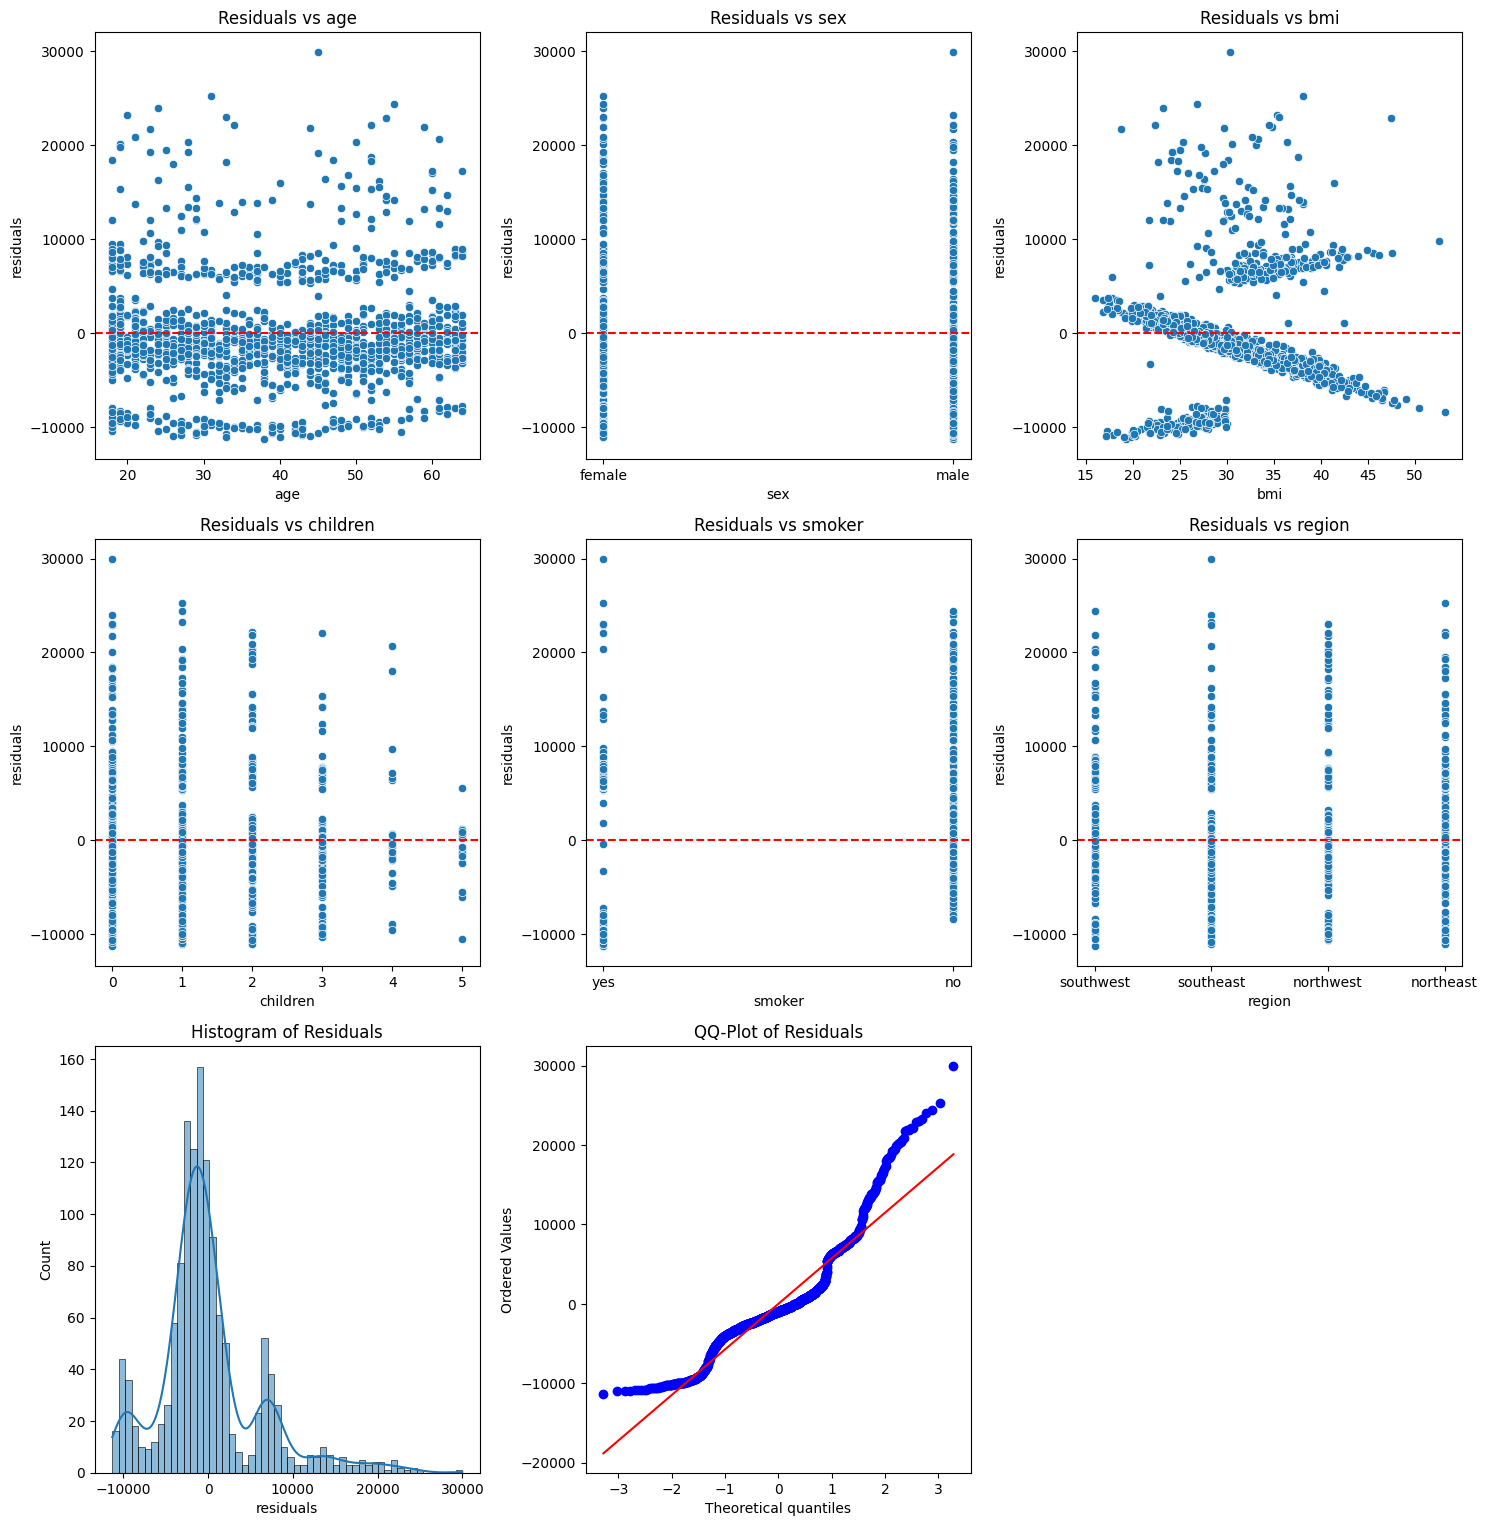

In [78]:
def plot_residuals(data, output_column, prediction_column, categorical_var=None):
    """
    Plot residuals of a model against all variables in the DataFrame. Additionally, plot
    a histogram and a QQ-plot of the residuals.

    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        output_column (str): The name of the output column.
        prediction_column (str): The name of the prediction column.
        categorical_var (str, optional): The name of a categorical variable for coloring. Defaults to None.
    """
    # TODO: As before, calculate residuals
    data['residuals'] = data[output_column] - data[prediction_column] 

    # Identify columns to plot (excluding the output and prediction columns)
    columns_to_plot = [col for col in data.columns if col not in [output_column, prediction_column, 'residuals']]

    # Number of rows and columns for the subplot
    n_cols = 3
    n_rows = int(len(columns_to_plot) / n_cols) + 2  # Additional row for histogram and QQ-plot

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # TODO: Plot each variable against the residuals
    for i, col in enumerate(columns_to_plot):
        ax = axes[i]
        
        if categorical_var and categorical_var in data.columns:
            sns.scatterplot(x = data[col], y = data["residuals"], data=data, ax=ax ,hue = None)
        else:
            sns.scatterplot(x = data[col], y = data["residuals"], data=data, ax=ax)
        
        ax.set_title(f'Residuals vs {col}')
        ax.axhline(0, ls='--', color='r')

    # Histogram of residuals
    sns.histplot(data['residuals'], kde=True, ax=axes[i + 1])
    axes[i + 1].set_title('Histogram of Residuals')

    # QQ-plot of residuals
    stats.probplot(data['residuals'], dist="norm", plot=axes[i + 2])
    axes[i + 2].set_title('QQ-Plot of Residuals')

    # Hide any unused axes
    for j in range(i + 3, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

data['predictions'] = model.predict(X)
# Example usage
plot_residuals(data, 'charges', 'predictions', 'smoker')


**What's happening with the residuals?**
> Write your answer here
-Vemos que en sex, el scatter nos revela que no hay un grupo que revele tener errores sistemáticamente mayores por lo que respecto a esta
variable parece bien elegido.
-En bmi si vemos unos resultados preocupantes, observamos tendencias en los errores que pueden estar sugiriendo una tendencia no lineal con bmi
-En childrens y region seguimos observando un buen comportamiento de los errores, que no se inclinan sistemáticamente hacia ninguna clase.
-En smoker notamos diferencias claras en errores, algo sospechoso.
>>Viendo el histograma, observamos que hay colas y no es un comportamiento normal centrado en 0 muy acertado. De hecho, el qq-plot nos lo termina de confirmar. Parece que el problema puede residir en la relacion con bmi y smoker...


# _Rolling in the deep_

Following the theory taught in class, do the following:

1. **implement the gradient descent algorithm** to train the linear regression model and reproduce the results using this training method. You can find the structure for the gradient descent inside the initial linear regression function, inside the method `fit_gradient_descent`.
2. As final steps, **display the progress of the loss function by plotting the gradient descent steps on the X-axis and the loss function on the Y-axis for each step**. 
3. Additionally, **using the same representation as in the previous section where each axis represents the values of w and b, show the sequence of steps that bring you closer to the optimum each time**. Each step should be a point in space, with coordinates (w,b). Compare all the results with the optimal solution from the scikit fit coefficients.

Feel free to add as many cells as you may need from here onwards in order to fulfill these three tasks

In [ ]:

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)

y = data["charges"].to_numpy(dtype=float)
X = data.drop(columns=["charges"]).to_numpy()

categorical_columns = [data.columns.get_loc(col) for col in ["sex", "smoker", "region"]]
X_encoded = one_hot_encode(X, categorical_columns, drop_first=True).astype(float)
# Estandarizamos
X_mean = X_encoded.mean(axis=0)
X_std  = X_encoded.std(axis=0)
X_std[X_std == 0] = 1.0 #con esto evitamos divisiones entre 0

X_gd = (X_encoded - X_mean) / X_std

y_mean = y.mean()
y_gd = y - y_mean

print(X_encoded.dtype, X_encoded.shape, y.dtype, y.shape)

float64 (1338, 8) float64 (1338,)


In [ ]:
def gradient_descent_with_history(X, y, learning_rate=1e-6, iterations=5000):
    m, n = X.shape
    
    #inicialización pequeña del gradient descent
    w = np.random.rand(n) * 0.01
    b = np.random.rand() * 0.01

    loss_history = []
    b_history = []
    w0_history = []   # guardamos solo w0 para el plot (w,b) como pide el enunciado

    for paso in range(iterations):
        y_pred = b + X @ w
        error = y_pred - y

        mse = np.mean(error**2)
        loss_history.append(mse)

        # guardar trayectoria
        b_history.append(b)
        w0_history.append(w[0])

        # gradientes de MSE
        db = (2/m) * np.sum(error)
        dw = (2/m) * (X.T @ error)

        # update
        b = b - learning_rate * db
        w = w - learning_rate * dw

    return b, w, np.array(loss_history), np.array(b_history), np.array(w0_history)

learning_rate = 1e-2
iterations = 5000

b_gd, w_gd, loss_hist, b_hist, w0_hist = gradient_descent_with_history(
    X_gd, y_gd,
    learning_rate=learning_rate,
    iterations=iterations
)

print("GD final b (scaled):", b_gd)
print("GD final w0 (scaled):", w_gd[0])
print("Final MSE:", loss_hist[-1])

GD final b (scaled): -4.093272613044695e-12
GD final w0 (scaled): 3607.472736194201
Final MSE: 36501893.00741544


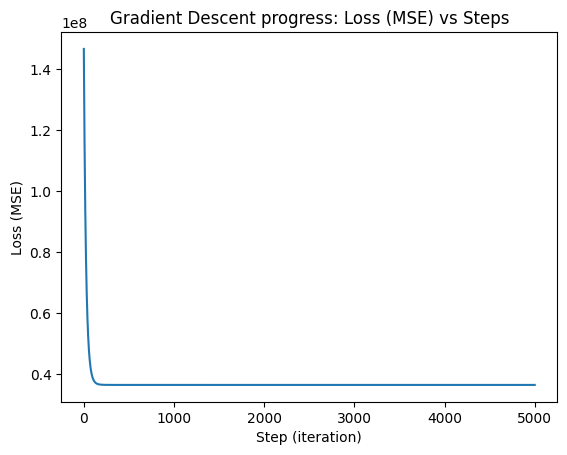

In [85]:
plt.figure()
plt.plot(np.arange(len(loss_hist)), loss_hist)
plt.title("Gradient Descent progress: Loss (MSE) vs Steps")
plt.xlabel("Step (iteration)")
plt.ylabel("Loss (MSE)")
plt.show()

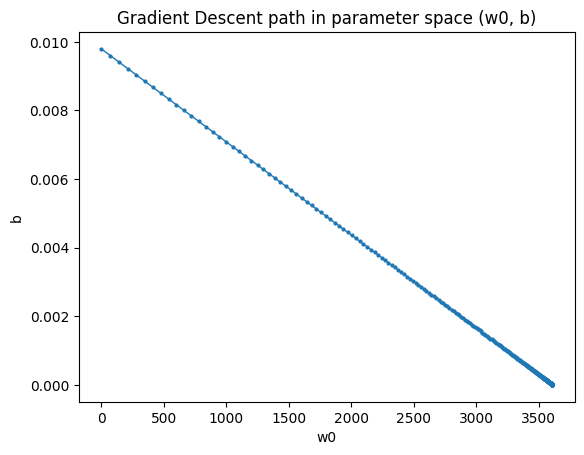

In [86]:
plt.figure()
plt.plot(w0_hist, b_hist, marker="o", markersize=2, linewidth=1)
plt.title("Gradient Descent path in parameter space (w0, b)")
plt.xlabel("w0")
plt.ylabel("b")
plt.show()

In [87]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression()
sk.fit(X_gd, y_gd)

print("SKLEARN intercept (b*) scaled:", sk.intercept_)
print("SKLEARN w0* scaled:", sk.coef_[0])

print("YOUR GD intercept (b) scaled:", b_gd)
print("YOUR GD w0 scaled:", w_gd[0])

SKLEARN intercept (b*) scaled: 2.509332316207118e-13
SKLEARN w0* scaled: 3607.472736194191
YOUR GD intercept (b) scaled: -4.093272613044695e-12
YOUR GD w0 scaled: 3607.472736194201


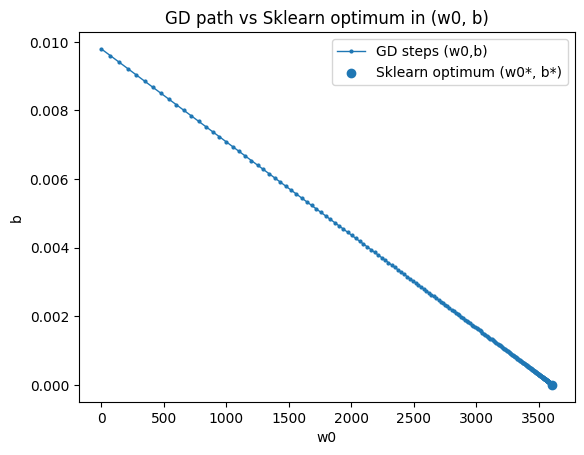

In [88]:
plt.figure()
plt.plot(w0_hist, b_hist, marker="o", markersize=2, linewidth=1, label="GD steps (w0,b)")
plt.scatter([sk.coef_[0]], [sk.intercept_], label="Sklearn optimum (w0*, b*)")
plt.title("GD path vs Sklearn optimum in (w0, b)")
plt.xlabel("w0")
plt.ylabel("b")
plt.legend()
plt.show()